In [1]:
# initialization
import numpy as np
# importing Qiskit
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit, transpile
from qiskit_aer import StatevectorSimulator, Aer
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
#from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# import basic plot tools
from qiskit.visualization import plot_histogram
%matplotlib inline

E.g n=3 Balanced funciton see how CX (which is x1 XOR x2 XOR x3) creates a balanced function.
The X gates we apply before is just to randomize the type of balanced fn
Just the XORs (ie CNOTS) create the balanced fn perfectly
but putting a X before oracle also is still balanced
it means there are many instances of abalnced fn
in the code we will randomly pick and s and put
x before all places where s[i]==1 we could have as well
put x randomly before any bit of s but given we choose s
itself randmly it is enuf randmization every time the fn 
is called. So for readablitly we simply put x gate whenever
s[i]==1 so we can reverse it later.

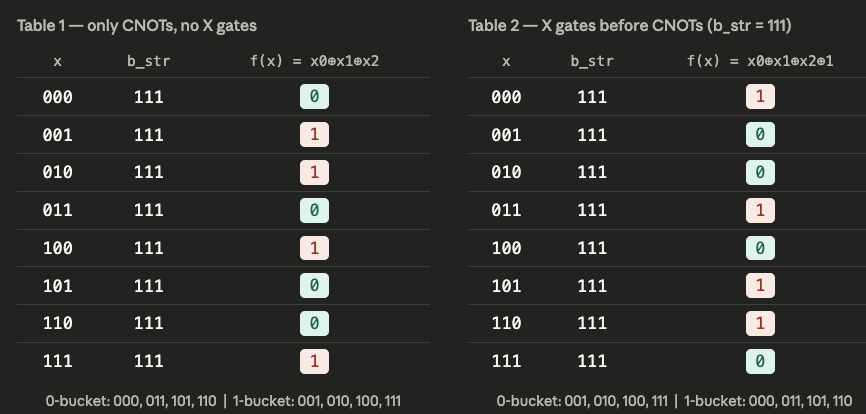

In [2]:
# create oracle functions

def constant_oracle(n):
    const_oracle = QuantumCircuit(n + 1) # extra 1 for the output
    if np.random.randint(2) == 0:
        return const_oracle
    else:
        const_oracle.x(n) # flip the output qubit
        return const_oracle

def balanced_oracle(n):
    balanced_oracle = QuantumCircuit(n+1) # extra 1 for the output
    
    # we are implementing balanced using s.xmod2 and we will choose a random 
    # s as follows
    s = np.random.randint(1, 2**n) # random integer between 1 and 2^n - 1
    s_binary_format = format(s, '0' + str(n) + 'b') # binary representation of s with leading zeros
    for i in range(n):
        if s_binary_format[i] == '1': # if the i-th bit of s is 1
            balanced_oracle.x(i) # apply X gate to the i-th input qubit
    
    balanced_oracle.barrier() # add a barrier for better visualization
    
    for i in range(n):
        balanced_oracle.cx(i, n) # apply CNOT from input qubit i to output qubit n

    balanced_oracle.barrier() # add a barrier for better visualization
    
    for i in range(n):
        if s_binary_format[i] == '1':
            balanced_oracle.x(i)

    return balanced_oracle


test_oracle = balanced_oracle(3)
print(test_oracle)


     ┌───┐ ░                 ░ ┌───┐
q_0: ┤ X ├─░───■─────────────░─┤ X ├
     ├───┤ ░   │             ░ ├───┤
q_1: ┤ X ├─░───┼────■────────░─┤ X ├
     ├───┤ ░   │    │        ░ ├───┤
q_2: ┤ X ├─░───┼────┼────■───░─┤ X ├
     └───┘ ░ ┌─┴─┐┌─┴─┐┌─┴─┐ ░ └───┘
q_3: ──────░─┤ X ├┤ X ├┤ X ├─░──────
           ░ └───┘└───┘└───┘ ░      


DJ Algorithm Diagram

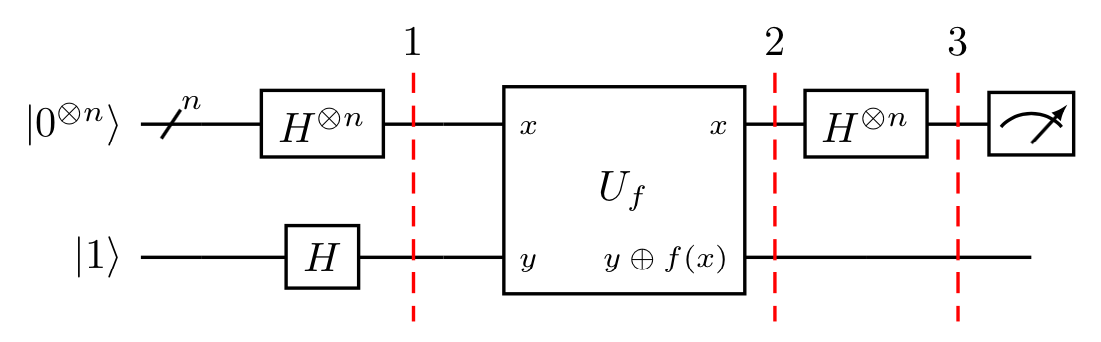

=========== DJ Algorithm on IBM Quantum Computer ===========


{'111': 1024}

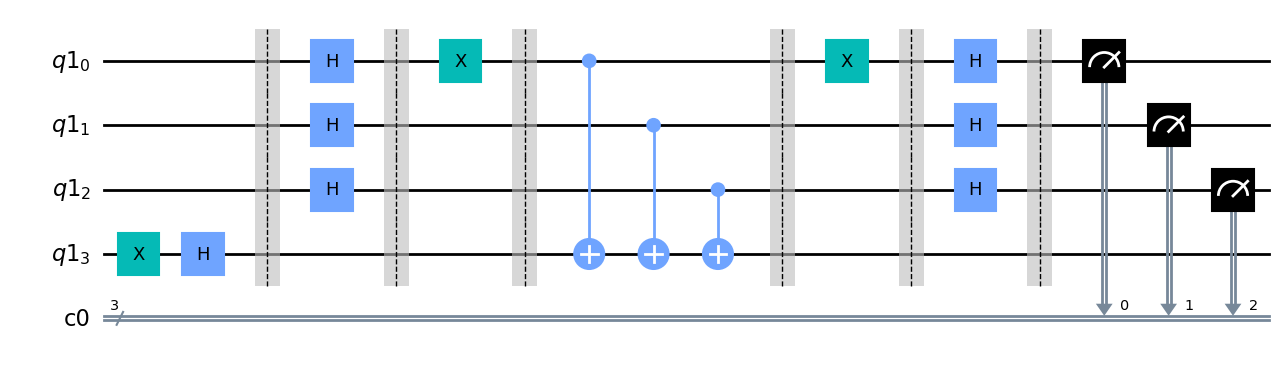

In [3]:
# implement the DJ algorthm with IBM Quantum Computer
class DJAlgorithm:
    def __init__(self, n, is_balanced):
        self.n = n
        self.is_balanced = is_balanced
        self.qr = QuantumRegister(n + 1) # n input qubits + 1 output qubit as ancilla
        self.cr = ClassicalRegister(n) # n classical bits to store the measurement results
        self.circuit = QuantumCircuit(self.qr, self.cr)

    def create_dj_circuit(self):
        # Step 1: Initialize the output qubit to |1>
        self.circuit.x(self.qr[self.n]) # flip the output qubit to |1>
        self.circuit.h(self.qr[self.n]) # apply H to the output qubit so |->
        self.circuit.barrier() # add a barrier for better visualization

        # Step 2: Apply H to all input qubits except the output qubit
        for i in range(self.n): # this creates range for 0 to n-1
            self.circuit.h(self.qr[i]) # apply H to input qubits

        self.circuit.barrier() # add a barrier for better visualization

        # Step 3: Apply the oracle function
        if self.is_balanced:
            oracle = balanced_oracle(self.n)
        else:            
            oracle = constant_oracle(self.n)

        self.circuit.compose(oracle, inplace=True) # apply the oracle to the circuit
        self.circuit.barrier() # add a barrier for better visualization

        # Step 4: Apply H to all input qubits except the output qubit
        for i in range(self.n):
            self.circuit.h(self.qr[i]) # apply H to input qubits

        self.circuit.barrier() # add a barrier for better visualization

        # Step 5: Measure the input qubits
        for i in range(self.n):
            self.circuit.measure(self.qr[i], self.cr[i]) # measure input qubits into classical bits 

        return self.circuit
    

    def run(self, simulate=True):
        circuit = self.create_dj_circuit()
        
        if(simulate):
            aer_sim = Aer.get_backend('aer_simulator')
            transpiled_circuit = transpile(circuit, aer_sim)
            result = aer_sim.run(transpiled_circuit).result()
            counts = result.get_counts(transpiled_circuit)
            return counts
        else:
            ''' service = QiskitRuntimeService(channel="ibm_quantum", token="YOUR_IBM_QUANTUM_API_TOKEN")
            backend = service.least_busy(simulator=False, operational=True)
            pass_mgr = generate_preset_pass_manager(backend=backend, optimization_level=1)
            pass_mgr_ciruit = pass_mgr.run(circuit)
            sampler = Sampler(backend)
            job = sampler.run(pass_mgr_ciruit)
            result = job.result()
            counts = result.get_counts(pass_mgr_ciruit)
            print("Ran on Quantum computer: ", counts)'''
            print("This part of the code is commented out because it requires access to an IBM Quantum computer")

print("=========== DJ Algorithm on IBM Quantum Computer ===========")

# Get the number of input qubits.
inputs_count = 3
function_type = 'b'

if function_type == 'c':
    DJAlgorithm(inputs_count, False).create_dj_circuit().draw('mpl', style='clifford')
elif function_type == 'b':
    DJAlgorithm(inputs_count, True).create_dj_circuit().draw('mpl', style='clifford')


DJAlgorithm(inputs_count, function_type == 'b').run(simulate=True)